In [1]:
	
import corneto as cn
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

import warnings

from corneto.methods.metabolism import evaluate_gpr_expression
from corneto._data import Data
from corneto.methods.future.imat import MultiSampleIMAT
sys.path.append(os.path.abspath('..'))

import Functions as custom

import gemsembler
from cobra.io import read_sbml_model
from gemsembler.downstream import pathway_of_interest

# Changing the media for this model

load the curratcurateded model from Elena

In [2]:
model = read_sbml_model("/scratch/rebernig/VR002_Model_Analysis/Output/Curated_Models_Elena/P.Vulgatus/Confidence_Levels_Biomass/curated.xml")

Load the media which I have created

In [3]:
LB_minus_O2_media = pd.read_csv("/scratch/rebernig/VR002_Model_Analysis/Scripts/Elenas_models/1_Media_LB_minus_02/LB_minus_O2_media.csv", index_col=0).squeeze().to_dict()

In [4]:
med_mod = {}
for e in model.exchanges:
    if (
        list(e.metabolites.keys())[0].id
        in LB_minus_O2_media
    ):
        med_mod.update({e.id: LB_minus_O2_media[list(e.metabolites.keys())[0].id]})
    else:
        med_mod.update({e.id: 0})
old_medium = model.medium
model.medium = med_mod
model.reactions.ATPM.lower_bound=5.54
res = model.optimize()
res

,fluxes,reduced_costs
LCADi,0.000000,-6.661338e-16
G6PI3,0.000000,-1.331149e-16
GHMT2r,14.343165,-1.607961e-16
GCALDt,0.000000,0.000000e+00
ACONT,0.000000,2.223035e-17
...,...,...
SERabc,0.000000,6.206368e-16
G3PAT180,0.336098,1.110223e-16
PGSA181,0.084025,5.423207e-16
PGPP181,0.084025,-1.874588e-15


In [5]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
arg__L_e,EX_arg__L_e,1.049,6,1.45%
ca2_e,EX_ca2_e,0.8127,0,0.00%
cl_e,EX_cl_e,0.04023,0,0.00%
cobalt2_e,EX_cobalt2_e,0.0001973,0,0.00%
cu2_e,EX_cu2_e,0.02443,0,0.00%
fe2_e,EX_fe2_e,0.1335,0,0.00%
fe3_e,EX_fe3_e,0.02443,0,0.00%
glc__D_e,EX_glc__D_e,10,6,13.85%
glu__L_e,EX_glu__L_e,10,5,11.54%
gly_e,EX_gly_e,10,2,4.62%


Because I have to provide my model now in a different way, I will reload it with cn.io.import_cobra_model and call it G

In [6]:
G = cn.io.cobra_model_to_graph(model)
df = pd.read_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Data_cleaning/Filtered_PV/filtered_PV.csv")
metadata = pd.read_csv("/scratch/rebernig/VR002_Model_Analysis/Data/Transcriptomics_Data_Juan/Pvulgatus/Pvulgatus_metadata.csv")

Change the name of the first column from "Name" to "gene"

In [7]:
df = df.rename(columns={"Name": "gene"})

In [8]:
print(df.columns)
print(metadata.columns)

Index(['gene', 'sample11', 'sample3', 'sample7', 'sample14', 'sample17',
       'sample20', 'sample45', 'sample46', 'sample85', 'sample15', 'sample18',
       'sample21'],
      dtype='object')
Index(['Sample_ID', 'Condition'], dtype='object')


In [9]:
# 1. Average replicates by condition
dataset = custom.average_expression_by_condition(df, metadata)
dataset.to_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Average_Expression/Pvulgatus")


In [10]:
# 2. Discretize PER CONDITION
from corneto._data import Data, Sample, Feature

samples_data = {}
edge_ids = list(G.get_attr_from_edges("id"))

for cond in dataset.columns[1:]:
    expr_vals = dataset[cond]
    _, thresholds = pd.qcut(expr_vals, q=3, retbins=True, labels=['low','neutral','high'])

    scores = pd.Series(0, index=dataset['gene'])
    high_mask = expr_vals >= thresholds[2]
    low_mask  = expr_vals <= thresholds[1]
    scores.iloc[high_mask.to_numpy()] = 1
    scores.iloc[low_mask.to_numpy()]  = -1

    gene_score = dict(zip(dataset['gene'], scores))
    rxn_scores = evaluate_gpr_expression(G.get_attr_from_edges("GPR"), gene_score)
    rxn_scores = np.nan_to_num(rxn_scores, nan=0.0)

    # Build a list of Feature objects for this condition
    features_list = [
        Feature(id=edge_id, value=score, mapping="edge")
        for edge_id, score in zip(edge_ids, rxn_scores)
    ]

    samples_data[cond] = Sample(features_list)

data = Data(samples_data)




Showing how the Discretization is done with a blot

In [11]:

import seaborn as sns

def plot_quantile_discretization(dataset, condition, log2p1=True, q=3, kde=True, bins=50, savepath=None):
    """
    Plot distribution of expression values for one condition with quantile cutoffs.
    
    dataset: DataFrame with ['gene', condition1, condition2, ...]
    condition: str, column name to plot
    savepath: optional, full file path where the plot should be saved (e.g. "out/condA.png")
    """
    # 1) get expression values
    vals = pd.to_numeric(dataset[condition], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if vals.empty:
        raise ValueError(f"No numeric values found for condition '{condition}'.")

    # 2) compute quantile thresholds
    qs = [i/q for i in range(1, q)]  
    tvals = vals.quantile(qs).values  
    t1, t2 = tvals[0], tvals[-1] if len(tvals) > 1 else (tvals[0], tvals[0])

    # 3) masks
    low_mask  = vals <= t1
    high_mask = vals >= t2
    neut_mask = ~(low_mask | high_mask)

    # 4) transform for plotting
    def tx(x): return np.log2(x + 1) if log2p1 else x
    plot_vals = tx(vals)
    t1p, t2p = tx(t1), tx(t2)

    # 5) plotting
    fig, ax = plt.subplots(figsize=(7,5))
    sns.histplot(plot_vals, bins=bins, stat="density", kde=kde, ax=ax, alpha=0.5)

    # quantile lines
    ax.axvline(t1p, ls='--', lw=1.5, color='k', label='1/3 quantile')
    ax.axvline(t2p, ls='--', lw=1.5, color='k', label='2/3 quantile')


    ax.set_xlabel(f"{condition} (log2(TPM+1))" if log2p1 else f"{condition} (TPM)")
    ax.set_ylabel("Density")
    ax.set_title(f"Discretization for '{condition}' (q={q})")

    # save if requested
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.tight_layout()
        plt.savefig(savepath, dpi=300)
        print(f"✅ Figure saved to {savepath}")

    plt.show()

    return {"t1": float(t1), "t2": float(t2), 
            "n_low": int(low_mask.sum()), 
            "n_neutral": int(neut_mask.sum()), 
            "n_high": int(high_mask.sum())}

✅ Figure saved to /scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Discretization_Blot/P.vulgatus.png


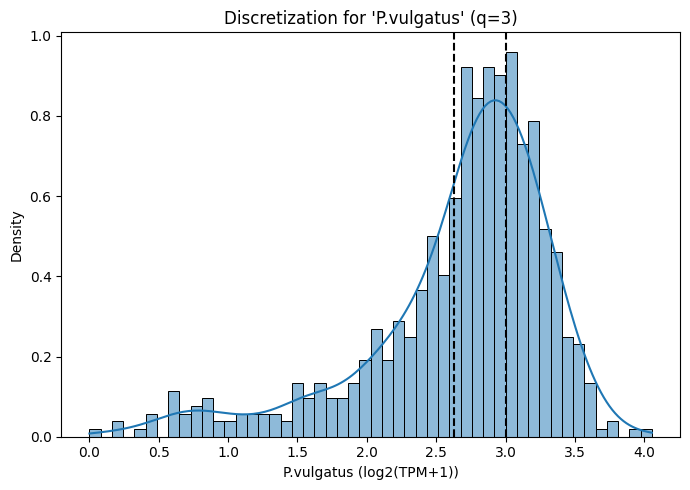

{'t1': 5.173371734719531,
 't2': 7.032332963285984,
 'n_low': 214,
 'n_neutral': 214,
 'n_high': 214}

In [12]:
plot_quantile_discretization(
    dataset,
    condition="P.vulgatus",
    savepath="/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Discretization_Blot/P.vulgatus.png"
)


In [13]:
print(dataset.columns)

Index(['gene', 'Com21', 'P.vulgatus', 'P.vulgatus + BTheta',
       'P.vulgatus + Buniformis'],
      dtype='object')


## Running iMAT

In [14]:
# 3. Build Data object for MultiSampleIMAT
# iMAT hyperparams
# 4. Run iMAT
m = MultiSampleIMAT(lambda_reg=0, eps=1e-2, use_bigm_constraints=True)
preprocessed_data = m.preprocess(G, data)
P = m.build(preprocessed_data[0], preprocessed_data[1])
P.solve(solver="glpk", verbosity=0)


Problem(Minimize(Expression(AFFINE, UNKNOWN, ())), [Inequality(Constant(CONSTANT, UNKNOWN, (1018, 4))), Inequality(Variable((1018, 4), _flow)), Equality(Expression(AFFINE, UNKNOWN, (823, 4)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, UNKNOWN, (1018, 4))), Inequality(Variable((1018, 4), _flow)), Inequality(Expression(AFFINE, NONNEGATIVE, (1018, 4))), Equality(Expression(AFFINE, NONNEGATIVE, (40, 4)), Constant(CONSTANT, ZERO, ())), Equality(Expression(AFFINE, NONNEGATIVE, (2540, 4)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, UNKNOWN, (1018, 4))), Inequality(Variable((1018, 4), _flow)), Inequality(Expression(AFFINE, NONNEGATIVE, (1018, 4))), Inequality(Expression(AFFINE, NONNEGATIVE, (1018,))), Inequality(Variable((1018,), edge_has_flux_OR, boolean=True))])

In [15]:
sample_names = list(data.samples.keys())
n_samples = len(sample_names)
k = 2  # if you know each sample has 2 components/objectives

condition_scores = {
    s_name: sum([P.objectives[s_idx + j*n_samples].value for j in range(k)])
    for s_idx, s_name in enumerate(sample_names)
}

df_scores = pd.DataFrame.from_dict(condition_scores, orient='index', columns=['iMAT_score'])
print(df_scores)

                         iMAT_score
Com21                         336.0
P.vulgatus                     24.0
P.vulgatus + BTheta           339.0
P.vulgatus + Buniformis        23.0


## Post iMAT


In [16]:
reaction_ids = G.get_attr_from_edges("id")

# Flux dataframe
df_fluxes = pd.DataFrame(
    P.expr.flow.value,
    index=reaction_ids,
    columns=sample_names  # same order as your data
)
df_fluxes.to_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/Pvulgatus")

array([[<Axes: title={'center': 'Com21'}>,
        <Axes: title={'center': 'P.vulgatus'}>],
       [<Axes: title={'center': 'P.vulgatus + BTheta'}>,
        <Axes: title={'center': 'P.vulgatus + Buniformis'}>]],
      dtype=object)

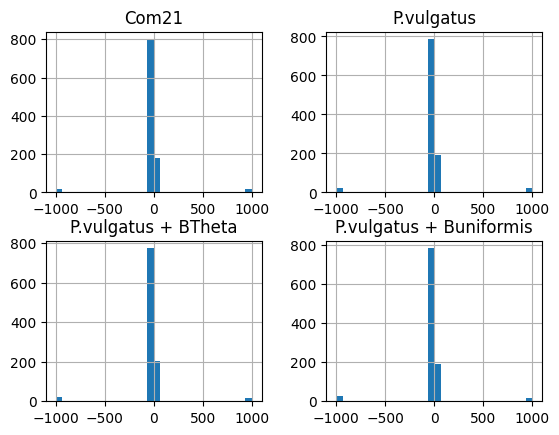

In [17]:
df_fluxes.hist(bins=30)


We logscale the data for plotting

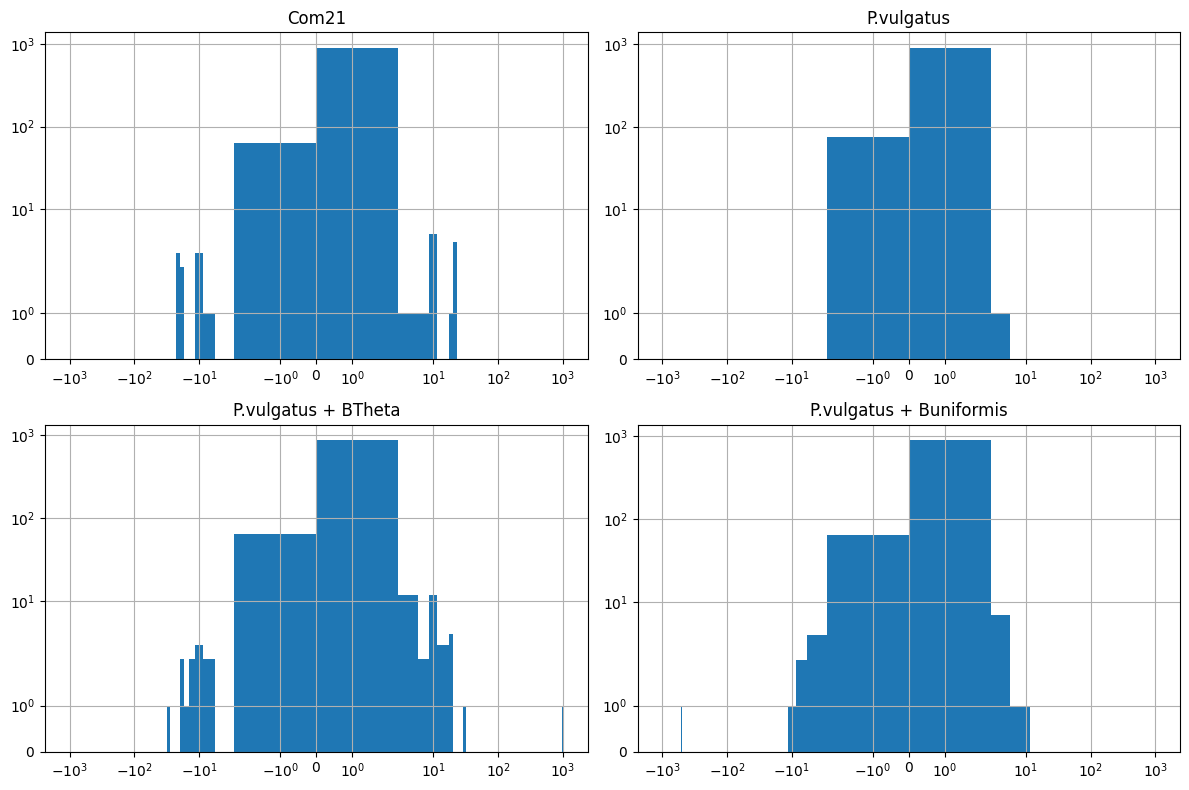

In [18]:
import matplotlib.pyplot as plt

axes = df_fluxes.hist(bins=700, figsize=(12, 8))

# Loop through each histogram axis and set symlog scaling for both x and y
for ax in axes.flatten():
    ax.set_xscale('symlog', base = 10)  # linear range around zero
    ax.set_yscale('symlog', base = 10)

plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/Pvulgatus_Plot")
plt.show()

In [19]:
df_fluxes

,Com21,P.vulgatus,P.vulgatus + BTheta,P.vulgatus + Buniformis
LCADi,0.000,0.000000,0.000000,0.00
G6PI3,-1000.000,-0.080000,-0.010000,0.02
GHMT2r,-0.010,0.040000,0.010000,-0.01
GCALDt,0.000,0.000000,0.000000,0.00
ACONT,-999.905,-999.593684,-997.033077,-999.72
...,...,...,...,...
SERabc,-0.000,0.010000,-0.000000,0.01
G3PAT180,0.000,0.000000,0.000000,0.00
PGSA181,0.000,0.000000,0.000000,0.00
PGPP181,0.000,0.000000,0.000000,0.00


In [20]:
def minmax_scale_rows_neg1_to_1(df):
    row_absmax = df.abs().max(axis=1).replace(0, pd.NA)
    scaled = df.div(row_absmax, axis=0)  # Broadcast divide per row
    return scaled

df_scaled = minmax_scale_rows_neg1_to_1(df_fluxes).replace(pd.NA,0)
print(df_scaled)

          Com21  P.vulgatus  P.vulgatus + BTheta  P.vulgatus + Buniformis
LCADi      0.00    0.000000             0.000000                 0.000000
G6PI3     -1.00   -0.000080            -0.000010                 0.000020
GHMT2r    -0.25    1.000000             0.250000                -0.250000
GCALDt     0.00    0.000000             0.000000                 0.000000
ACONT     -1.00   -0.999689            -0.997128                -0.999815
...         ...         ...                  ...                      ...
SERabc    -0.00    1.000000            -0.000000                 1.000000
G3PAT180   0.00    0.000000             0.000000                 0.000000
PGSA181    0.00    0.000000             0.000000                 0.000000
PGPP181    0.00    0.000000             0.000000                 0.000000
Biomass    0.00    0.000000             0.000000                 0.000000

[1018 rows x 4 columns]


/tmp/ipykernel_706307/501621218.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_scaled = minmax_scale_rows_neg1_to_1(df_fluxes).replace(pd.NA,0)


In [21]:
df_scaled

,Com21,P.vulgatus,P.vulgatus + BTheta,P.vulgatus + Buniformis
LCADi,0.00,0.000000,0.000000,0.000000
G6PI3,-1.00,-0.000080,-0.000010,0.000020
GHMT2r,-0.25,1.000000,0.250000,-0.250000
GCALDt,0.00,0.000000,0.000000,0.000000
ACONT,-1.00,-0.999689,-0.997128,-0.999815
...,...,...,...,...
SERabc,-0.00,1.000000,-0.000000,1.000000
G3PAT180,0.00,0.000000,0.000000,0.000000
PGSA181,0.00,0.000000,0.000000,0.000000
PGPP181,0.00,0.000000,0.000000,0.000000


In [22]:
df_scaled.to_csv('/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/Pvulgatus_df_scaled')

Remove all Reaction where flux values are 0 for all condititions

In [23]:
# Remove rows where all values are 0
df_scaled_nonzero = df_scaled[(df_scaled != 0).any(axis=1)]

print(f"Before: {df_scaled.shape[0]} reactions")
print(f"After: {df_scaled_nonzero.shape[0]} reactions")
df_scaled_nonzero

Before: 1018 reactions
After: 374 reactions


,Com21,P.vulgatus,P.vulgatus + BTheta,P.vulgatus + Buniformis
G6PI3,-1.000000e+00,-0.000080,-0.000010,0.000020
GHMT2r,-2.500000e-01,1.000000,0.250000,-0.250000
ACONT,-1.000000e+00,-0.999689,-0.997128,-0.999815
G6PBDH,2.000000e-05,-0.999920,0.000000,-1.000000
G6PI,-9.999800e-01,-1.000000,-0.000010,-0.999980
...,...,...,...,...
ASNt2r,-1.000000e+00,-1.000000,0.000000,-1.000000
OCDCAt2,1.000000e+00,-0.000000,0.000010,-0.000000
THMDt2,4.437774e-08,1.000000,0.000010,-0.000010
THMt2,-1.000000e+00,0.000000,0.000000,0.000000


Next we calculate the variablity of conditions per flux. Only the 50 highest variablitiys are taken

In [24]:
# Calculate row variance
row_var = df_scaled_nonzero.var(axis=1)

# Keep top 50 most variable
df_top_var = df_scaled_nonzero.loc[row_var.sort_values(ascending=False).head(50).index]

df_top_var

,Com21,P.vulgatus,P.vulgatus + BTheta,P.vulgatus + Buniformis
HPYRRy,-1.000000e+00,-1.000000e+00,1.000000,-1.000000e+00
HPYRRx,1.000000e+00,1.000000e+00,-1.000000,1.000000e+00
URIDK2r,0.000000e+00,1.000000e+00,-1.000000,1.000000e+00
NDPK3,-1.000000e-05,9.999900e-01,-1.000000,9.999900e-01
PYK4,1.000000e-05,1.000000e+00,-0.999990,1.000000e+00
THRt4,-4.899556e-04,1.000000e+00,-1.000000,-9.999400e-01
THRt2r,4.899556e-04,-9.998700e-01,1.000000,1.000000e+00
NAt3_1,-1.000000e-05,1.000000e+00,-0.000010,-1.000000e+00
NDPK2,3.000000e-05,-2.588947e-03,1.000000,-9.999700e-01
PYK2,-1.000000e-05,-2.618947e-03,0.999970,-1.000000e+00


CLustered Heatmap

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

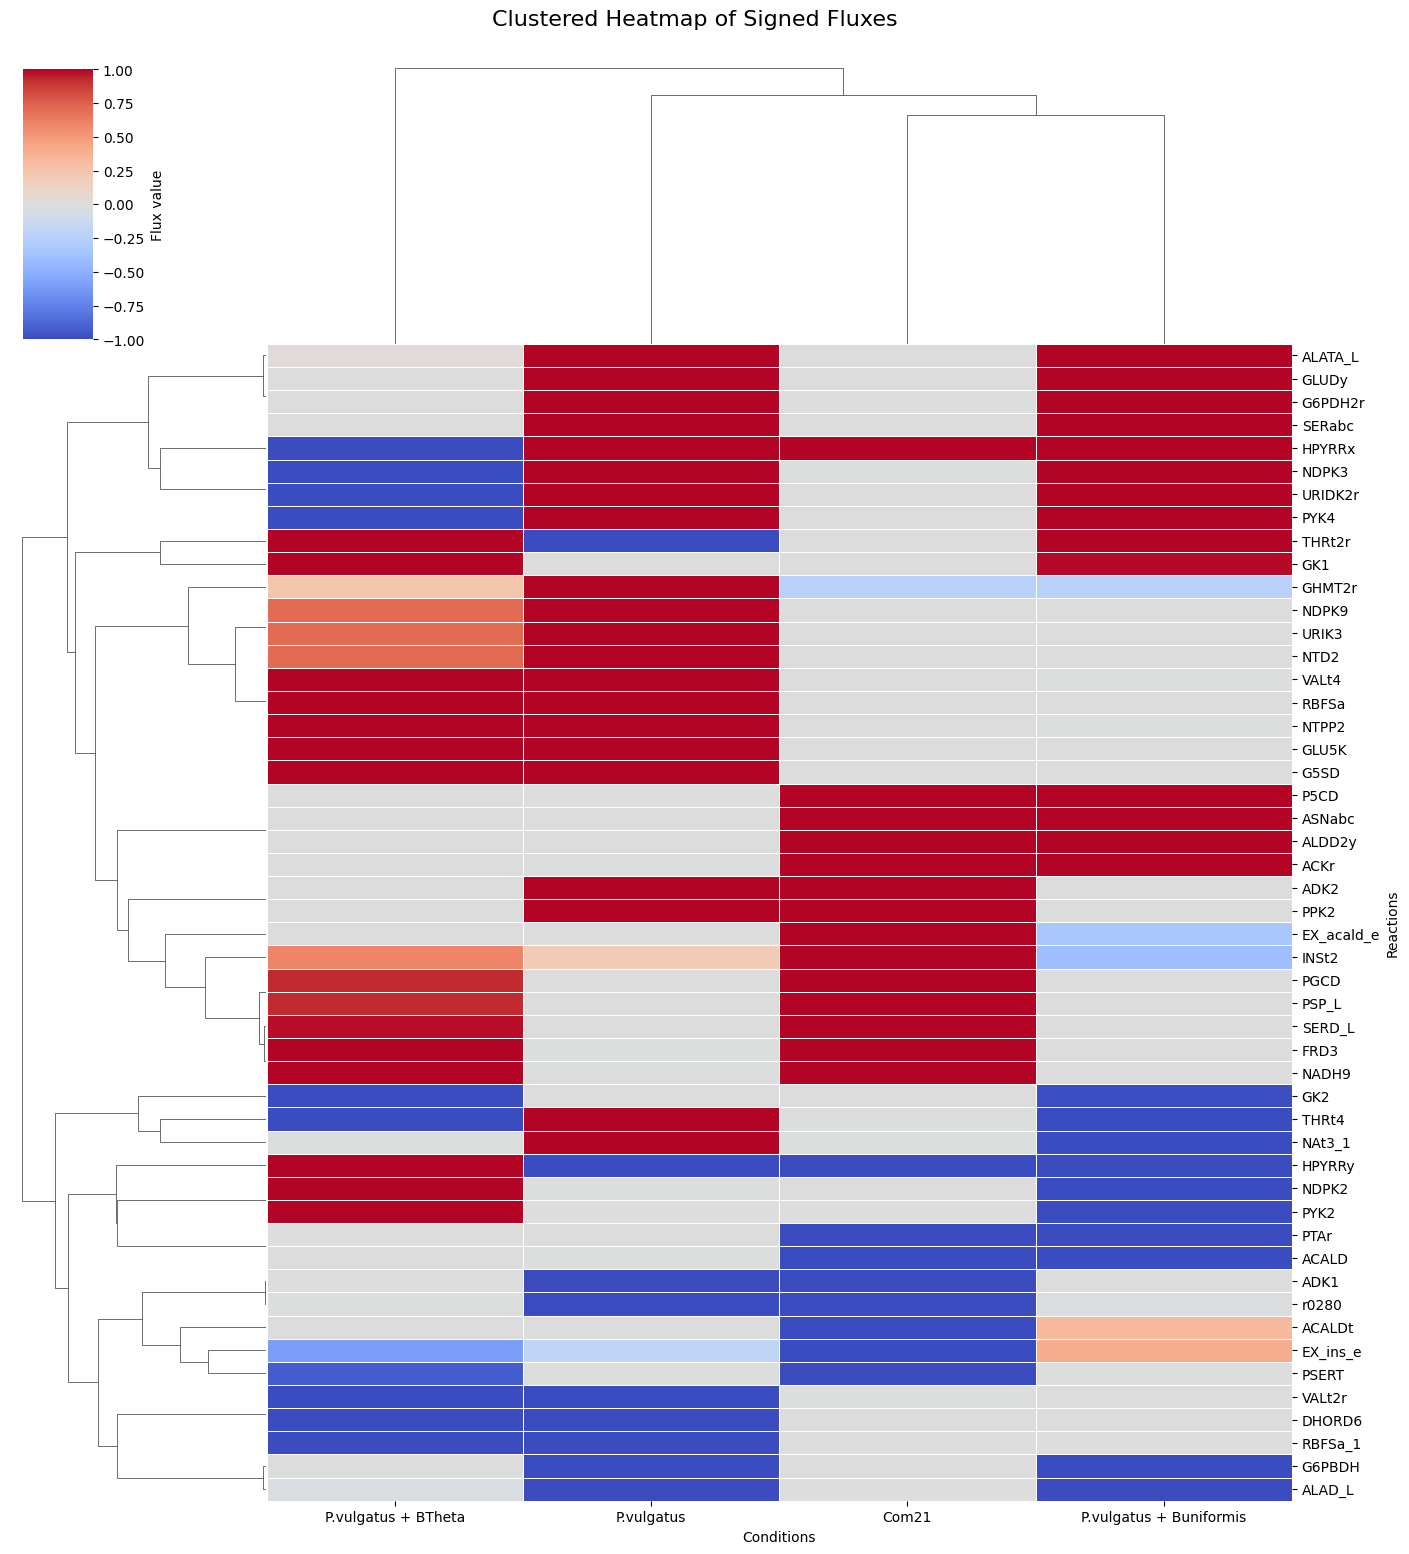

In [26]:
# 2. Create a clustered heatmap
g = sns.clustermap(
    df_top_var,
    cmap="coolwarm",         # blue=negative, white=zero, red=positive
    center=0,                # zero will be white
    figsize=(14, 15),
    linewidths=0.5,
    cbar_kws={"label": "Flux value"}
)

# 3. Label axes
g.ax_heatmap.set_xlabel("Conditions")
g.ax_heatmap.set_ylabel("Reactions")

plt.suptitle("Clustered Heatmap of Signed Fluxes", y=1.02, fontsize=16)
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/Pvulgatus_reaction_heatmap")



## Picking out examples 

In [33]:
df_fluxes.loc["THRt2r"]

Com21                         0.489956
P.vulgatus                 -999.870000
P.vulgatus + BTheta        1000.000000
P.vulgatus + Buniformis    1000.000000
Name: THRt2r, dtype: float64

## Looking at interesting reaction in our model

I will first create a list of all the reaction names which have a significant difference depending on the condiiton

In [28]:
reaction_list = df_top_var.index.tolist()
reaction_list

['HPYRRy',
 'HPYRRx',
 'URIDK2r',
 'NDPK3',
 'PYK4',
 'THRt4',
 'THRt2r',
 'NAt3_1',
 'NDPK2',
 'PYK2',
 'INSt2',
 'EX_ins_e',
 'GHMT2r',
 'VALt4',
 'ADK1',
 'G6PDH2r',
 'NTPP2',
 'P5CD',
 'EX_acald_e',
 'ACALDt',
 'DHORD6',
 'GLU5K',
 'G5SD',
 'ASNabc',
 'SERabc',
 'FRD3',
 'NADH9',
 'RBFSa_1',
 'RBFSa',
 'G6PBDH',
 'VALt2r',
 'ADK2',
 'PPK2',
 'GLUDy',
 'ALDD2y',
 'PTAr',
 'ACKr',
 'GK2',
 'GK1',
 'r0280',
 'ACALD',
 'SERD_L',
 'ALAD_L',
 'ALATA_L',
 'PSERT',
 'PGCD',
 'PSP_L',
 'URIK3',
 'NTD2',
 'NDPK9']

In [29]:
from gemsembler.downstream import pathway_of_interest

from gemsembler import read_supermodel_from_json


In [30]:
supermodel1 = read_supermodel_from_json("/scratch/rebernig/VR002_Model_Analysis/Output/Supermodels_Elena/supermodel_pv.json")

loading supermodel...
loading SetofNewElements...
loading SetofNewElements...
loading SetofNewGenes...


In [31]:

graf, table = pathway_of_interest(supermodel1, reaction_list,
draw_pathway_to_file ="/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/flux_map/Pvulgatus.html",
write_table_to_file = "/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/flux_map/Pvulgatus.tsv")

Making PCA analysis in the end

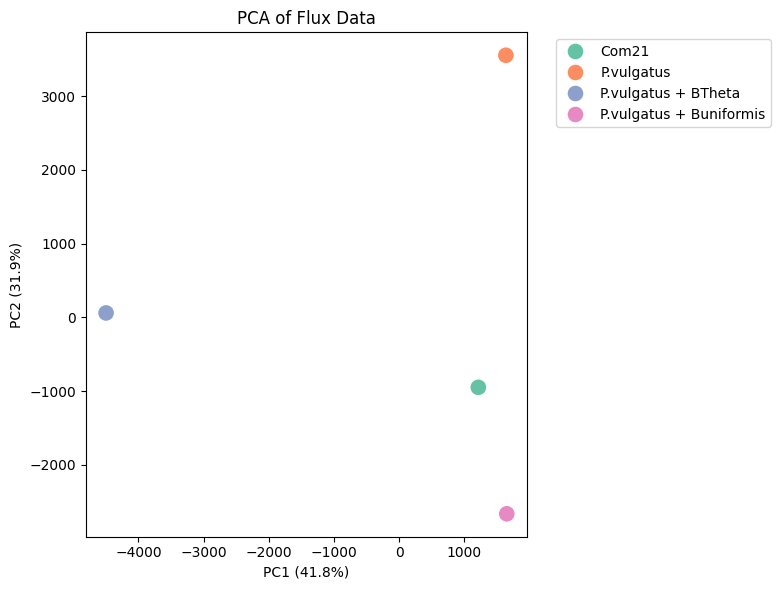

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Transpose so PCA runs on reactions as features
df_fluxes_T = df_fluxes.T 

# Run PCA
pca = PCA(n_components=2)
pc = pca.fit_transform(df_fluxes_T)

# Make dataframe for plotting
pca_df = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=df_fluxes_T.index)
pca_df['Condition'] = pca_df.index  # since your index = condition names

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Condition', s=150, palette="Set2")
plt.title('PCA of Flux Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/Pvulgatus_PCA")
plt.show()